# Welcome to the post-simulation Tutorial of the single lens system! 

In this tutorial, we will be extracting the following information from the post-processed data:
1) Verifying the aperture profile and the corresponding far field beams with industry standard softwares such as CST and GRASP.
2) Calculating the poynting vector $\textbf{S}$ from the $\textbf{E}$ and $\textbf{H}$ fields.
3) Analysing the Scalar Product between the Poynting Vector components of time-forward and time-reverse simulations.

First, let's write some functions to properly extract the E-field and H-field depending on the different frequencies!

In [7]:
import numpy as np
import os
import matplotlib.pyplot as plt

def load_fields(basepath, freq, filename):
    # Construct the full path to the file
    filepath = os.path.join(basepath, 'freq_{}GHz'.format(freq), filename)
    # Load the fields stored in npz files
    data = np.load(filepath)

    return data

basepath = os.path.join('../time-reverse/simple_single_lens_ARC/output_files/')
freq = 90.0  # Frequency in GHz
e_filename = 'efield_timeavg.npz'
h_filename = 'hfield_timeavg.npz'
xyzw_filename = 'xyzw.npz'
e_data = load_fields(basepath, freq, e_filename)
h_data = load_fields(basepath, freq, h_filename)
xyzw_data = load_fields(basepath, freq, xyzw_filename)
print("E-field data keys:", e_data.files)
print("H-field data keys:", h_data.files)
print("XYZW data keys:", xyzw_data.files)


E-field data keys: ['ex_real', 'ex_imag', 'ey_real', 'ey_imag', 'ez_real', 'ez_imag', 'count']
H-field data keys: ['hx_real', 'hx_imag', 'hy_real', 'hy_imag', 'hz_real', 'hz_imag', 'count']
XYZW data keys: ['x_coords', 'y_coords', 'weights']


Now since the 2D simulations are done in TE mode polarization, so only the Ez, Hx, Hy component survives. We can filter the data for reducing memory (This might be very useful for full scale telescope simulated data since they might be sometimes in the order of multiple GBs)

In [5]:
# Filter the TE component (Ez, Hx, Hy)
ez = e_data['ez_real'] + 1j * e_data['ez_imag']
hx = h_data['hx_real'] + 1j * h_data['hx_imag']
hy = h_data['hy_real'] + 1j * h_data['hy_imag']

Now lets calculate the corresponding poynting vector $\textbf{S}$. The Poynting vector components in TE mode are:

$S_x = -E_z \cdot H_y^*$

$S_y = E_z \cdot H_x^*$

In [9]:
# S vector components for TE mode
sx = -ez * np.conj(hy)
sy = ez * np.conj(hx)
sx_mag = np.abs(sx)
sy_mag = np.abs(sy)
s_total = np.sqrt(sx_mag**2 + sy_mag**2)
s_total_db = 10 * np.log10(s_total / np.max(s_total) + 1e-20)  # in dB
# efield magnitude
ez_power = np.abs(ez)**2
ez_power_db = 10 * np.log10(ez_power / np.max(ez_power) + 1e-20)  # in dB

Let's plot the Poynting vector magnitude and efield power

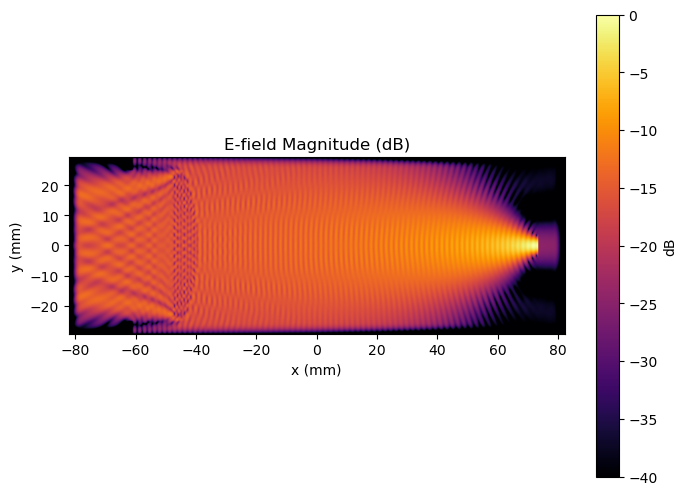

<Figure size 640x480 with 0 Axes>

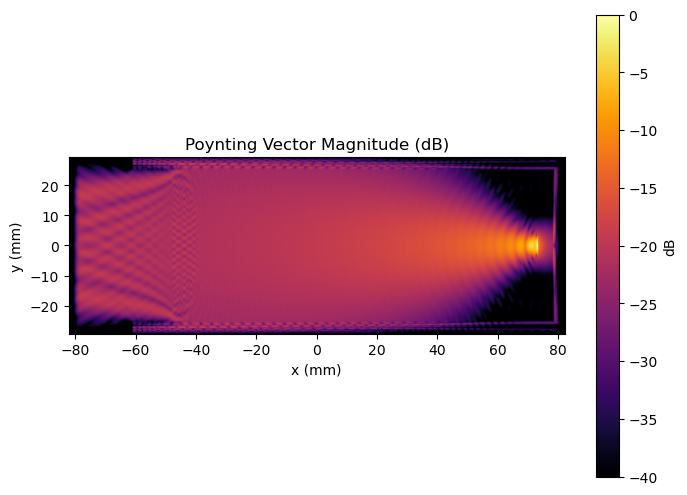

<Figure size 640x480 with 0 Axes>

In [17]:
def plot_field(simname, field_db, title, filename, xcoords, ycoords, vmin=-40, vmax=0, savepath= os.path.join('../../processed_data/'),
                show_plots=True):
    plt.figure(figsize=(8, 6))
    plt.imshow(field_db.T, extent=(xcoords[0], xcoords[-1], ycoords[0], ycoords[-1]),
               origin='lower', cmap='inferno', vmin=vmin, vmax=vmax)
    plt.colorbar(label='dB')
    plt.title(title)
    plt.xlabel('x (mm)')
    plt.ylabel('y (mm)')

    if show_plots:
        plt.show()

    if savepath and not os.path.exists(os.path.join(savepath, simname)):
        os.makedirs(os.path.join(savepath, simname))
    plt.savefig(os.path.join(savepath, simname, filename), dpi=300)

# E-field plot
plot_field(simname = 'simple_single_lens_ARC', 
            field_db=ez_power_db, 
            title='E-field Magnitude (dB)', 
            filename='ez_magnitude_db.png', 
            xcoords=xyzw_data['x_coords'], 
            ycoords=xyzw_data['y_coords'])
# S-vector plot
plot_field(simname = 'simple_single_lens_ARC', 
            field_db=s_total_db, 
            title='Poynting Vector Magnitude (dB)', 
            filename='s_magnitude_db.png', 
            xcoords=xyzw_data['x_coords'], 
            ycoords=xyzw_data['y_coords'])